In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
df = pd.read_csv('/content/drive/MyDrive/Case_Study_03/dataset.csv')

print(df.head())

# veri bilgisi
print(df.info())

   Unnamed: 0                     tesisat_no_id    il    ilce  \
0           0  208e38ba076e428c9e5c9d9c0bd53f3f  ORDU  Gölköy   
1           1  208e38ba076e428c9e5c9d9c0bd53f3f  ORDU  Gölköy   
2           2  208e38ba076e428c9e5c9d9c0bd53f3f  ORDU  Gölköy   
3           3  208e38ba076e428c9e5c9d9c0bd53f3f  ORDU  Gölköy   
4           4  208e38ba076e428c9e5c9d9c0bd53f3f  ORDU  Gölköy   

  gerilim_seviyesi  marka          model                 abone_grubu  \
0               OG  MAKEL  C500.KMY.2251  Tek Terimli Ticarethane OG   
1               OG  MAKEL  C500.KMY.2251  Tek Terimli Ticarethane OG   
2               OG  MAKEL  C500.KMY.2251  Tek Terimli Ticarethane OG   
3               OG  MAKEL  C500.KMY.2251  Tek Terimli Ticarethane OG   
4               OG  MAKEL  C500.KMY.2251  Tek Terimli Ticarethane OG   

   son_carpan_degeri   l1     l2    l3      v1      v2      v3          t0  \
0                  1  0.0  64.67  0.01  233.75  222.62  232.08  415005.784   
1                  1

In [13]:
#Tarih Kolonunun Düzenlenmesi
df['load_profile_date'] = pd.to_datetime(df['load_profile_date'])
#zaman
df['hour'] = df['load_profile_date'].dt.hour
df['day'] = df['load_profile_date'].dt.day
df['month'] = df['load_profile_date'].dt.month


In [14]:
missing_values = df.isnull().sum()
missing_ratio = (missing_values / len(df)) * 100

missing_table = pd.DataFrame({
    "Eksik Sayı": missing_values,
    "Eksik %": missing_ratio
})

print(missing_table)

#Eksik Veri Analizi Kontrolü
df['v1'].fillna(df['v1'].median(), inplace=True)
df['v2'].fillna(df['v2'].median(), inplace=True)
df['v3'].fillna(df['v3'].median(), inplace=True)


                   Eksik Sayı    Eksik %
Unnamed: 0                  0   0.000000
tesisat_no_id               0   0.000000
il                          0   0.000000
ilce                        0   0.000000
gerilim_seviyesi            0   0.000000
marka                       0   0.000000
model                       0   0.000000
abone_grubu                 0   0.000000
son_carpan_degeri           0   0.000000
l1                          0   0.000000
l2                          0   0.000000
l3                          0   0.000000
v1                      75434  21.312110
v2                      75434  21.312110
v3                      75434  21.312110
t0                          0   0.000000
ri                      10240   2.893072
rc                      10240   2.893072
load_profile_date           0   0.000000
hour                        0   0.000000
day                         0   0.000000
month                       0   0.000000


/tmp/ipykernel_780/109116312.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['v1'].fillna(df['v1'].median(), inplace=True)
/tmp/ipykernel_780/109116312.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [15]:
df = df[df["t0"] >= 0]

In [16]:
#Ortalama Akım
df['avg_current'] = (df['l1'] + df['l2'] + df['l3']) / 3
#Ortalama Gerilim
df['avg_voltage'] = (df['v1'] + df['v2'] + df['v3']) / 3
#Faz Dengesizliği
df['phase_imbalance'] = df[['l1','l2','l3']].max(axis=1) - df[['l1','l2','l3']].min(axis=1)


In [17]:
#Tüketim Farkı
df = df.sort_values(['tesisat_no_id','load_profile_date'])
df['consumption_diff'] = df.groupby('tesisat_no_id')['t0'].diff()


In [18]:
def time_period(hour):

    if 0 <= hour < 6:
        return "gece"

    elif 6 <= hour < 18:
        return "gunduz"

    else:
        return "aksam"

df["time_period"] = df["hour"].apply(time_period)

In [20]:
#Akım olduğu ancak tüketim olmadığı
df['anom_current_no_consumption'] = (df['avg_current'] > 0) & (df['consumption_diff'] == 0)

#Tüketim var ancak akım düşük
df['anom_meter_fault'] = (df['consumption_diff'] > 0) & (df['avg_current'] < 1)

#Faz dengesizliği
df['anom_phase_imbalance'] = df['phase_imbalance'] > 20

#Gerilim eksik ama tüketim var
df["anomaly_voltage_missing"] = (
    (df[["v1","v2","v3"]].isnull().any(axis=1)) &
    (df["consumption_diff"] > 0)
)

#Toplam anomali skor
df['anomaly_score'] = (
df['anom_current_no_consumption'].astype(int)+
df['anom_meter_fault'].astype(int)+
df['anom_phase_imbalance'].astype(int)+
df['anomaly_voltage_missing'].astype(int))


In [21]:
anomali_il = df.groupby("il")["anomaly_score"].sum().sort_values(ascending=False)

print(anomali_il)

il
ÇORUM     121210
SAMSUN     16144
ORDU        9769
SİNOP       8138
AMASYA       990
Name: anomaly_score, dtype: int64


In [22]:
anomali_ilce = df.groupby("ilce")["anomaly_score"].sum().sort_values(ascending=False)

print(anomali_ilce)

ilce
Osmancık      41020
Merkez        30292
İskilip       26047
Alaca         17732
Ayancık        7717
Havza          7112
Sungurlu       6676
Gölköy         5783
Bafra          5158
Fatsa          3903
İlkadım        2107
Kavak           896
Atakum          831
Bayat           324
Taşova          239
Boğazkale       152
Altınordu        83
Merzifon         82
Türkeli          28
Hamamözü         21
Vezırköprü       20
Terme            19
Gerze             8
Salıpazarı        1
Name: anomaly_score, dtype: int64


In [23]:
riskli_abone = df.groupby("tesisat_no_id")["anomaly_score"].sum()

riskli_abone = riskli_abone.sort_values(ascending=False).head(10)

print(riskli_abone)

tesisat_no_id
dbfad8ca481441f296cd1ca7c70016a5    5896
b2efcb5df4674abeb3bdf34292c1a0fa    5875
0a6bce9bc9a945c0acbd8c048cb1e0a0    5859
1d44073ce0ee4c1db06185c236b09c79    5859
fddc974a8ced46c88c811504bcbc4d1d    5851
d9174516af614967bf17ac4aa860051a    5839
d7a38b85cd1c4238a10bd6182d8978b1    5829
8427aeeb82794ea598d7e93621c89dcb    5829
1191285bf78d4901ac2bc3ef47139832    5825
a6d27c3a132a4d43831628c17c9ddcf1    5816
Name: anomaly_score, dtype: int64


In [24]:
daily_anomaly = df.groupby(df["load_profile_date"].dt.date)["anomaly_score"].sum()

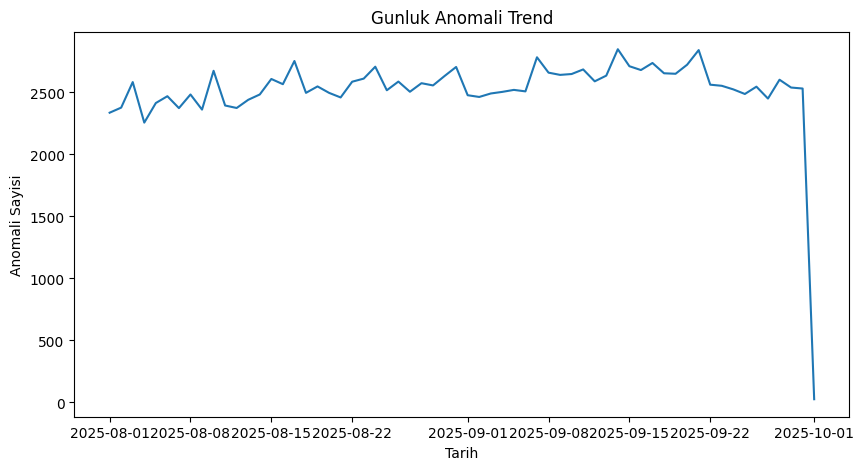

In [25]:
import matplotlib.pyplot as plt

#Sonuçlar
plt.figure(figsize=(10,5))
daily_anomaly.plot()
plt.title("Gunluk Anomali Trend")
plt.xlabel("Tarih")
plt.ylabel("Anomali Sayisi")
plt.show()

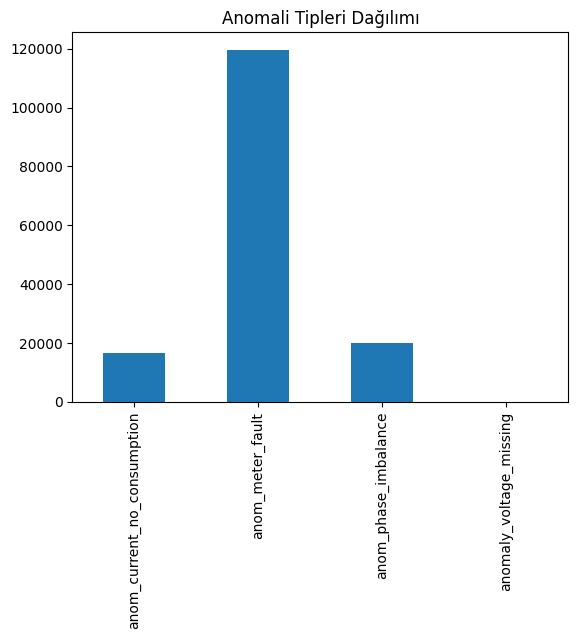

In [28]:
anomaly_types = [
    "anom_current_no_consumption",
    "anom_meter_fault",
    "anom_phase_imbalance",
    "anomaly_voltage_missing"
]

df[anomaly_types].sum().plot(kind="bar")

plt.title("Anomali Tipleri Dağılımı")
plt.show()